# Searching for the category

For this code along we are only going to use the products DataFrame. However, if you believe there is information in other tables that can help to create categories, please feel free to explore.

In [ ]:
import pandas as pd

In [ ]:
# products_cl.csv
url = "https://drive.google.com/file/d/1IPnKYLSnrST0HBZMeSeNrhFfWU31QvwB/view?usp=drive_link"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
products_cl = pd.read_csv(path)
product_category_df = products_cl.copy()

# orderlines_cl.csv
url = "https://drive.google.com/file/d/1OhtkQS2fwOYdzfd-qPh7im35iLc-L9TA/view?usp=sharing"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
orderlines_cl = pd.read_csv(path)
orderlines_df = orderlines_cl.copy()

# orders_c.csv
url = "https://drive.google.com/file/d/1Tla62vfu__kCqvgypZyVt2S9VuC016yH/view?usp=sharing"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
orders_cl = pd.read_csv(path)
orders_df = orders_cl.copy()

# Create new categories with .str method

In [ ]:
# 1. Initialize the category column with an empty string
product_category_df = products_cl.copy()
product_category_df["category"] = ""

In [ ]:
# 1. Classify Input Devices (Mice and Keyboards) using names and descriptions
contiene_mouse_kbd = product_category_df["name"].str.contains("mouse|keyboard", case=False, na=False) | product_category_df["desc"].str.contains("mouse|keyboard", case=False, na=False)
product_category_df.loc[contiene_mouse_kbd, "category"] += ", Keyboard"

# 2. Classify Apple Mobile Devices (Smartphones and iPods)
# Expanded lookahead window to 20 characters to capture refurbished or "Like new" item prefixes
product_category_df.loc[product_category_df["name"].str.contains("^.{0,20}apple iphone|iphone", case=False, na=False), "category"] += ", Smartphone"
product_category_df.loc[product_category_df["name"].str.contains("^.{0,20}apple ipod|ipod", case=False, na=False), "category"] += ", Ipod"

# Classify Tablet Accessories (Styluses, Pointers, and Digital Pens)
is_stylus = product_category_df["name"].str.contains("stylus|pointer|digital pen|adonit", case=False, na=False) | product_category_df["desc"].str.contains("stylus|pointer|digital pen", case=False, na=False)
product_category_df.loc[is_stylus, "category"] += ", Tablet"

# Classify Desktop Computers and Monitors
product_category_df.loc[product_category_df["name"].str.contains("imac|mac mini|mac pro|monitor|desktop", case=False, na=False), "category"] += ", Desktop"

# 3. Classify Laptop Computers (MacBook Pro, MacBook Air)
product_category_df.loc[product_category_df["name"].str.contains("macbook", case=False, na=False), "category"] += ", Laptop"

# 4. Classify Storage, Networking, and Infrastructure Devices
product_category_df.loc[product_category_df["name"].str.contains("disc|hard drive|hard disk|ssd|external drive|drive|hub|raid|crucial|sandisk|lacie|toshiba|western digital|memory|kingston|jetdrive|aura|expansion|network|qnap|nas|synology|router|wifi|wi-fi|ifixit", case=False, na=False), "category"] += ", Storage"

# 5. Classify Protective Gear and Accessories
product_category_df.loc[product_category_df["name"].str.contains("folio|glass|tripod|case|cover|sleeve|bag|shell|backpack|protector|support|stand", case=False, na=False), "category"] += ", Protection"

# 6. Classify Cables, Adapters, and Power Accessories
product_category_df.loc[product_category_df["name"].str.contains("thunderbolt|hdmi|magsafe|cable|adapter|charger|power|lightning|connect|dock|battery", case=False, na=False), "category"] += ", Cable_Adapter"

# 7. Classify Audio and Video Electronics
product_category_df.loc[product_category_df["name"].str.contains("speaker|airpods|headphone|earphone|speaker|microphone|headset|drone|gopro|sonos|bose|jbl|beats|audio|sound", case=False, na=False), "category"] += ", Audio"

# 8. Classify Smartwatches and Wearable Accessories
product_category_df.loc[product_category_df["name"].str.contains("belt|correa|strap|fitbit|clock|withings|apple watch|smartwatch|watch", case=False, na=False), "category"] += ", Smartwatch"

# 9. Classify Professional Services and Warranties
product_category_df.loc[product_category_df["name"].str.contains("repair|service|applecare|warranty|installation|labor|setup", case=False, na=False), "category"] += ", Service"

# 10. Classify Smart Home Devices and Gadget Ecosystems
product_category_df.loc[product_category_df["name"].str.contains("sensor|motion|hue|bulb|smart|switch|camera|eve|elgato", case=False, na=False), "category"] += ", Smart_home"


In [ ]:
# ==============================================================================
# FINAL CATEGORIZATION PRIORITY AND CLEANING PIPELINE
# ==============================================================================

# 1. Services take absolute precedence over hardware categories
product_category_df.loc[product_category_df["category"].str.contains("Service", na=False), "category"] = "Service"

# 2. Reclassify expansion kits and components as Storage, overriding primary hardware tags
is_kit = product_category_df["name"].str.contains("kit|upgrade|expansion|enlargement", case=False, na=False)
product_category_df.loc[product_category_df["category"].str.contains("Laptop", na=False) & is_kit, "category"] = "Storage"
product_category_df.loc[product_category_df["category"].str.contains("Smartphone", na=False) & is_kit, "category"] = "Storage"

# 3. Reclassify laptop bags and protective sleeves under the Protection category
is_bag = product_category_df["name"].str.contains("backpack|bag|case|sleeve|shell|cover|folio", case=False, na=False)
product_category_df.loc[product_category_df["category"].str.contains("Laptop", na=False) & is_bag, "category"] = "Protection"

# 4. Reclassify mobile accessories and photography mounts under the Protection category
is_selfie_gadget = product_category_df["name"].str.contains("pack|selfie|trigger|monopod|mount|tripod", case=False, na=False)
product_category_df.loc[product_category_df["category"].str.contains("Smartphone", na=False) & is_selfie_gadget, "category"] = "Protection"

# 5. Consolidate audio devices into the final Audio & Video category
product_category_df.loc[product_category_df["category"].str.contains("Audio", na=False), "category"] = "Audio & Video"

# 6. Resolve multi-category overlaps by prioritizing main hardware devices over general accessory keywords
is_not_accessory = ~product_category_df["name"].str.contains("case|cover|sleeve|protector|glass|stand|support|holder|shield", case=False, na=False)
product_category_df.loc[product_category_df["category"].str.contains("Smartphone", na=False) & is_not_accessory, "category"] = "Smartphone"

product_category_df.loc[product_category_df["category"].str.contains("Tablet", na=False), "category"] = "Tablet"
product_category_df.loc[product_category_df["category"].str.contains("Laptop", na=False), "category"] = "Laptop"
product_category_df.loc[product_category_df["category"].str.contains("Desktop", na=False), "category"] = "Desktop"
product_category_df.loc[product_category_df["category"].str.contains("Ipod", na=False), "category"] = "Ipod"
product_category_df.loc[product_category_df["category"].str.contains("Smartwatch", na=False), "category"] = "Smartwatch"

# 7. Apply standard string formatting to the remaining standalone accessory categories
product_category_df.loc[product_category_df["category"].str.contains("Storage", na=False), "category"] = "Storage"
product_category_df.loc[product_category_df["category"].str.contains("Protection", na=False), "category"] = "Protection"
product_category_df.loc[product_category_df["category"].str.contains("Cable_Adapter", na=False), "category"] = "Cable & Adapter"
product_category_df.loc[product_category_df["category"].str.contains("Keyboard", na=False), "category"] = "Keyboard"
product_category_df.loc[product_category_df["category"].str.contains("Smart_home", na=False), "category"] = "Smart home"

# 8. Perform final string stripping and assign unclassified records to the "Other" fallback category
product_category_df["category"] = product_category_df["category"].str.lstrip(", ")
product_category_df.loc[product_category_df["category"] == "", "category"] = "Other"

# 9. Output final distribution of cleaned categories
print("--- FINAL CLEANED CATEGORY DISTRIBUTION ---")
print(product_category_df["category"].value_counts())


--- FINAL CLEANED CATEGORY DISTRIBUTION ---
category
Storage            2686
Protection         2155
Desktop            1184
Laptop              709
Cable & Adapter     677
Smartphone          533
Audio & Video       488
Other               485
Smartwatch          433
Service             197
Smart home          163
Tablet              149
Ipod                 70
Keyboard             63
Name: count, dtype: int64


# Plots for the board

In [ ]:
# 1. Change the name in order_id column in orderlines_
orderlines_df = orderlines_df.rename(columns={"id_order": "order_id"})

# 2. Take only completed orders
orders_df = orders_df.loc[orders_df["state"] == "Completed", :]

# 3. Keep only the "order_id" in orderlines_df that are in orders_df (all = Completed)
orderlines_df = orderlines_df.loc[orderlines_df["order_id"].isin(orders_df["order_id"]), :]

# 4. Keep only the "order_id" in orders_df that are in orderlines_df
orders_df = orders_df.loc[orders_df["order_id"].isin(orderlines_df["order_id"]), :]

# Check
print("Unique order_id:", orders_df["order_id"].nunique())
print("Unique order_id:", orderlines_df["order_id"].nunique())


Unique order_id: 43064
Unique order_id: 43064


In [ ]:
# Merge orderlines with product_category dataframe
orderlines_products = orderlines_df.merge(product_category_df, on="sku", how="left")
orderlines_products = orderlines_products[["date","order_id","product_quantity","name","desc","price","unit_price","category"]]

# Calculate discount in % per each row
discount_percentage = (((orderlines_products["price"] - orderlines_products["unit_price"]) / orderlines_products["price"]) * 100).round(2)
orderlines_products["discount_percentage"] = discount_percentage

# Group discount in % per each category
orderlines_products.groupby("category")["discount_percentage"].mean().round(2).sort_values(ascending=False)


,discount_percentage
category,
Protection,31.29
Cable & Adapter,30.63
Audio & Video,25.19
Smartwatch,22.16
Service,21.32
Other,20.98
Laptop,20.77
Desktop,19.23
Tablet,17.69


In [ ]:
# 1. Calculate the theoretical revenue for each single line item (quantity * discounted unit price)
orderlines_df["unit_price_total"] = orderlines_df["unit_price"] * orderlines_df["product_quantity"]

# 2. Group by order ID to calculate the total accumulated value of all products within each cart
grouped_orderlines = orderlines_df.groupby("order_id", as_index=False)["unit_price_total"].sum()

# 3. Perform a left merge to attach the calculated cart totals to the main orders DataFrame
comparison_df = orders_df.merge(grouped_orderlines, on="order_id", how="left")

# 4. Calculate the net financial difference (Total paid minus the sum of cart product values)
comparison_df["price_diff"] = comparison_df["total_paid"] - comparison_df["unit_price_total"]

# 5. Apply the Interquartile Range (IQR) method to filter out price anomalies and statistical outliers
q25_diff = comparison_df["price_diff"].quantile(0.25)
q75_diff = comparison_df["price_diff"].quantile(0.75)
iqr_diff = q75_diff - q25_diff

# Calculate outlier thresholds
lower_bound_diff = q25_diff - (1.5 * iqr_diff)
upper_bound_diff = q75_diff + (1.5 * iqr_diff)

# Filter the DataFrame to retain only orders within the acceptable statistical bounds
comparison_df = comparison_df[
    (comparison_df["price_diff"] >= lower_bound_diff) &
    (comparison_df["price_diff"] <= upper_bound_diff)
]

# 6. Output the final clean distribution parameters after removing data outliers
print("\n--- FINAL CLEANED DISTRIBUTION WITH IQR ---")
print(comparison_df["price_diff"].describe().round(2))



--- FINAL CLEANED DISTRIBUTION WITH IQR ---
count    42311.00
mean         3.92
std          2.85
min         -5.00
25%          0.00
50%          4.99
75%          6.99
max         16.97
Name: price_diff, dtype: float64


In [ ]:
# 1. Filter products to retain ONLY those belonging to orders within the clean IQR threshold
# Added .copy() to isolate the DataFrame and permanently prevent the SettingWithCopyWarning
orderlines_clean = orderlines_products.loc[orderlines_products["order_id"].isin(comparison_df["order_id"]), :].copy()

# 2. Recalculate the real transaction revenue column on the cleaned dataset
orderlines_clean['transaction_revenue'] = orderlines_clean['product_quantity'] * orderlines_clean['unit_price']

# 3. Group by category, aggregate total revenue, round values, and sort in descending order
classifica_revenue_pulita = orderlines_clean.groupby("category")["transaction_revenue"].sum().round(2).sort_values(ascending=False)

# 4. Output the final revenue ranking distribution by category
print("--- CLEANED REVENUE RANKING BY CATEGORY ---")
print(classifica_revenue_pulita)

# 5. Verify the final absolute total revenue sum across all categories
print("\nTotal consolidated clean revenue:", round(classifica_revenue_pulita.sum(), 2), "€")


--- CLEANED REVENUE RANKING BY CATEGORY ---
category
Storage            3032214.73
Smartphone         1428214.95
Desktop             972665.34
Audio & Video       509389.30
Other               379705.74
Laptop              345362.96
Protection          303012.95
Smartwatch          272437.92
Cable & Adapter     232055.79
Tablet              147256.09
Service             112864.31
Keyboard            110762.13
Smart home           70742.89
Ipod                 16862.56
Name: transaction_revenue, dtype: float64

Total consolidated clean revenue: 7933547.66 €


## 1. Price list distribution by Category

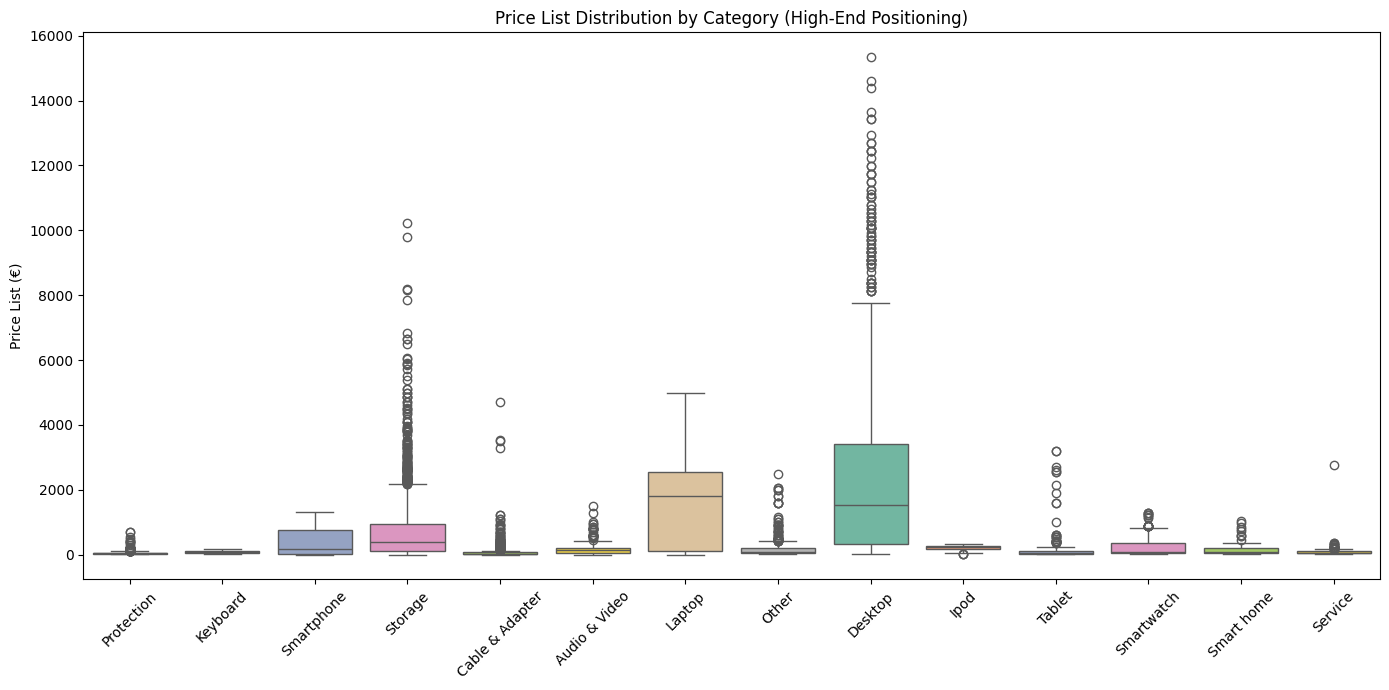

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Initialize the figure size for optimal visualization padding
plt.figure(figsize=(14, 7))

# 2. Generate the boxplot distribution per category
# Added hue and disabled legend to comply with modern Seaborn syntax guidelines
sns.boxplot(
    data=product_category_df,
    x="category",
    y="price",
    palette="Set2",
    hue="category",
    legend=False
)

# 3. Rotate X-axis labels by 45 degrees to prevent text overlap
plt.xticks(rotation=45)

# 4. Configure descriptive chart titles and clear axis labels
plt.title("Price List Distribution by Category (High-End Positioning)")
plt.xlabel("") # Left blank to prevent redundancy since category names are self-explanatory
plt.ylabel("Price List (€)")

# 5. Apply tight layout bounds and render the plot
plt.tight_layout()
plt.show()


## Analysis of Unit Sales Volumes against Average Category Discount Rates


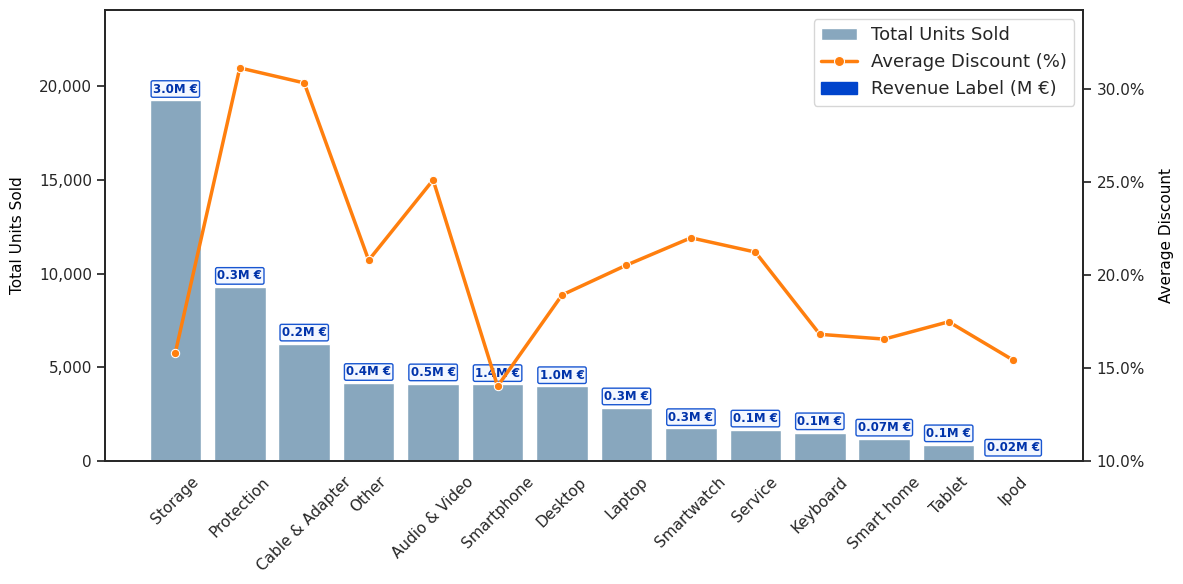

In [ ]:
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Aggregate data: Sum total quantities, average discounts, and sum total real revenue per category
category_data = (
    orderlines_clean.groupby("category")
    .agg(
        total_units=("product_quantity", "sum"),        # Sum of units sold (represented by Bars)
        avg_discount=("discount_percentage", "mean"),   # Average discount percentage (represented by Line)
        total_revenue=("transaction_revenue", "sum")    # Total real transaction revenue
    )
    .sort_values(by="total_units", ascending=False)
    .reset_index()
)

# 2. Apply a clean white theme to the plot background
sns.set_theme(style="white")

# 3. Initialize the primary axes for the unit volume bar chart (Left Y-axis)
fig, ax1 = plt.subplots(figsize=(12, 6))

barplot = sns.barplot(
    data=category_data,
    x="category",
    y="total_units",
    color="#7fa9c7",  # Light blue hue
    ax=ax1,
    label="Total Units Sold"
)

# DYNAMIC OVERLAY: Generate clean data labels for real transaction revenue (M €) above each bar
for i, bar in enumerate(barplot.patches):
    revenue_val = category_data.loc[i, "total_revenue"]
    height = bar.get_height()

    # Format the revenue value into a compact millions representation (e.g., 3.0M €)
    revenue_text = f"{revenue_val/1e6:.1f}M €" if revenue_val >= 100000 else f"{revenue_val/1e6:.2f}M €"

    ax1.text(
        bar.get_x() + bar.get_width() / 2.0,
        height + 250,  # Safety margin spacing above the bar height apex
        revenue_text,
        ha="center",
        va="bottom",
        fontsize=8.5,       # Minimalist font sizing to optimize spacing layout
        fontweight="bold",
        color="#0033aa",    # Dark blue font to indicate monetary values
        bbox=dict(
            boxstyle="round,pad=0.15", # Compact structural boundary bounding box
            fc="#f2f7ff",   # Ultra-light blue-white canvas background fill tint
            ec="#0044cc",   # Coordinated blue structural border stroke
            lw=1,
            alpha=0.9,
        ),
    )

# Configure primary left Y-axis styles, ticks, and padding boundaries
ax1.set_xlabel("")
ax1.set_ylabel("Total Units Sold", color="black", fontsize=11, labelpad=10)
ax1.tick_params(axis="x", rotation=45, labelsize=11)
ax1.tick_params(axis="y", labelsize=11)

# Format primary Y-axis numbers to display thousand-separator layout ticks
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:,.0f}"))

# ANTI-OVERLAP OPTIMIZATION: Expand the Y-axis upper limit ceiling to 125% to leave sufficient padding for bounding text boxes
ax1.set_ylim(bottom=0, top=category_data["total_units"].max() * 1.25)

# 4. Initialize the secondary axes for the discount percentage line chart (Right Y-axis)
ax2 = ax1.twinx()

sns.lineplot(
    data=category_data,
    x="category",
    y="avg_discount",
    color="#ff7f0e",  # Orange accent hue
    marker="o",       # Circular markers for data intersection points
    linewidth=2.5,
    ax=ax2,
    sort=False,        # Restricts Seaborn from re-sorting categorical bar sequencing
    label="Average Discount (%)"
)

# Configure secondary right Y-axis styles, ticks, and bounds
ax2.set_ylabel("Average Discount", color="black", fontsize=11, labelpad=10)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.1f}%"))
ax2.tick_params(axis="y", labelsize=11)
ax2.grid(False)
ax2.set_ylim(bottom=10, top=category_data["avg_discount"].max() * 1.1)

# 5. CONSOLIDATED LEGEND DESIGN: Unify separate axis metrics into a single box to prevent canvas clutter
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

if ax1.get_legend() is not None:
    ax1.get_legend().remove()

# Generate a complementary blue proxy patch to explicitly document revenue data labels in the legend schema
revenue_patch = mpatches.Patch(color="#0044cc", label="Revenue Label (M €)")

ax2.legend(
    handles=lines1 + lines2 + [revenue_patch],
    loc="upper right",
    frameon=True,
    prop={'size': 13},  # High-readability font sizing optimized for presentation slides
    markerscale=1.2
)

plt.tight_layout()
plt.show()


## Revenue Generation vs. Unit Volume Across Product Categories

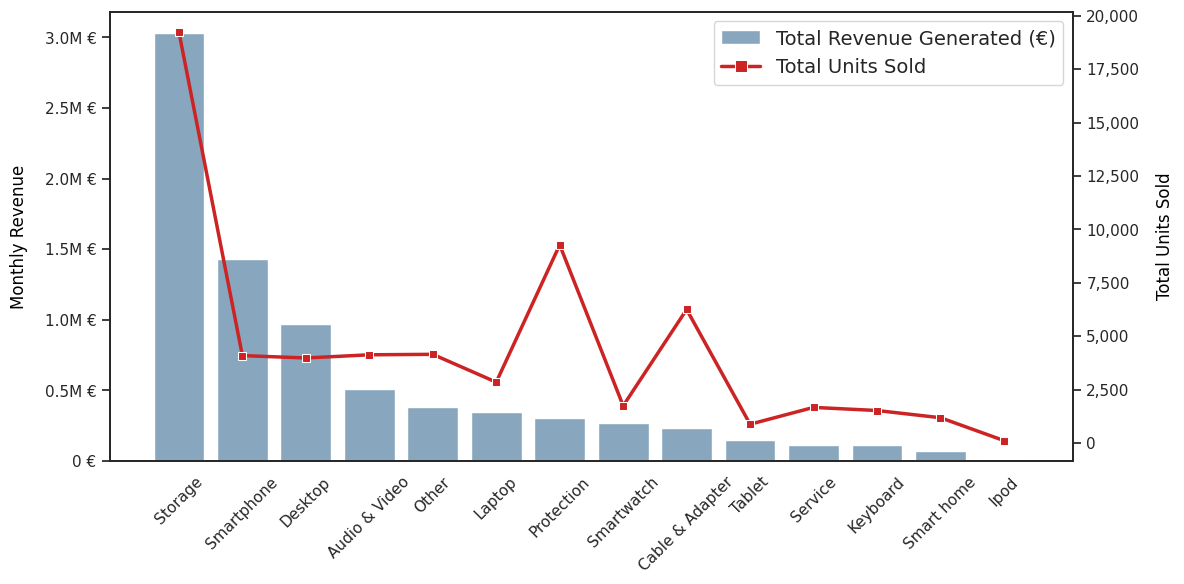

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Aggregate and sort data by total revenue in descending order for the visualization
category_revenue_volume = (
    orderlines_clean.groupby("category")
    .agg(
        total_revenue=("transaction_revenue", "sum"),
        total_units=("product_quantity", "sum")
    )
    .sort_values(by="total_revenue", ascending=False)
    .reset_index()
)

# 2. Set a clean white theme for the plot background
sns.set_theme(style="white")

# 3. Initialize the primary axes for the revenue bar chart (Left Y-axis)
fig, ax1 = plt.subplots(figsize=(12, 6))

sns.barplot(
    data=category_revenue_volume,
    x="category",
    y="total_revenue",
    color="#7fa9c7",  # Professional steel blue hue
    ax=ax1,
    label="Total Revenue Generated (€)"
)

# Configure primary left Y-axis style, ticks, and layout parameters
ax1.set_xlabel("")
ax1.set_ylabel("Monthly Revenue", color="black", fontsize=12, labelpad=12)

# Format primary Y-axis labels to a compact millions layout (e.g., "1.5M €")
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M €" if x != 0 else "0 €"))

ax1.tick_params(axis="x", rotation=45, labelsize=11)
ax1.tick_params(axis="y", labelsize=11)

# 4. Initialize the secondary axes for the unit volume line chart (Right Y-axis)
ax2 = ax1.twinx()

sns.lineplot(
    data=category_revenue_volume,
    x="category",
    y="total_units",
    color="#cc2424",  # Crimson red hue
    marker="s",       # Square markers for data intersection points
    linewidth=2.5,
    ax=ax2,
    sort=False,        # Restricts Seaborn from re-sorting categorical bar sequencing
    label="Total Units Sold"
)

# Configure secondary right Y-axis style, ticks, and bounds
ax2.set_ylabel("Total Units Sold", color="black", fontsize=12, labelpad=12)

# Format secondary Y-axis numbers to display thousand-separator layout ticks
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:,.0f}"))
ax2.tick_params(axis="y", labelsize=11)
ax2.grid(False)

# 5. Consolidated Legend Design: Unify separate axis metrics into a single box
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

if ax1.get_legend() is not None:
    ax1.get_legend().remove()

ax2.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="upper right",
    frameon=True,
    prop={"size": 14},  # Optimized legend scaling for presentation slide clarity
    markerscale=1.5
)

plt.tight_layout()
plt.show()
